In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV,StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
import pickle

In [2]:
df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df = df.drop('customerID', axis=1)

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
columns = df.select_dtypes(exclude=[np.number]).columns

for col in columns:
    print(f"{col} : {df[col].unique()} unique values")
    print('---'*20)

gender : ['Female' 'Male'] unique values
------------------------------------------------------------
Partner : ['Yes' 'No'] unique values
------------------------------------------------------------
Dependents : ['No' 'Yes'] unique values
------------------------------------------------------------
PhoneService : ['No' 'Yes'] unique values
------------------------------------------------------------
MultipleLines : ['No phone service' 'No' 'Yes'] unique values
------------------------------------------------------------
InternetService : ['DSL' 'Fiber optic' 'No'] unique values
------------------------------------------------------------
OnlineSecurity : ['No' 'Yes' 'No internet service'] unique values
------------------------------------------------------------
OnlineBackup : ['Yes' 'No' 'No internet service'] unique values
------------------------------------------------------------
DeviceProtection : ['No' 'Yes' 'No internet service'] unique values
---------------------------------

In [12]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

In [14]:
df['TotalCharges'].isna().sum()

np.int64(0)

Classdistribtion of the target class

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Insights:
1. customerID removed as it is not required for modelling
2. No missing values in the dataset
3. Missing values in the TtoalCarges colummns were replaced by 0
4. Class imbalanceed identified in the target column

EDA

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Numerical Feature analysis

In [17]:
def plot_histogram(df, column):
    plt.figure(figsize=(5, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    mean_value = df[column].mean()
    median_value = df[column].median()

    plt.axvline(mean_value, color='red', linestyle='--', label=f'Mean: {mean_value:.2f}')
    plt.axvline(median_value, color='blue', linestyle='--', label=f'Median: {median_value:.2f}')
    
    plt.legend()
    plt.show() 

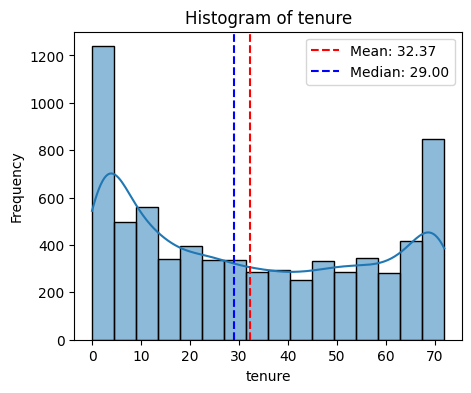

In [18]:
plot_histogram(df, 'tenure')


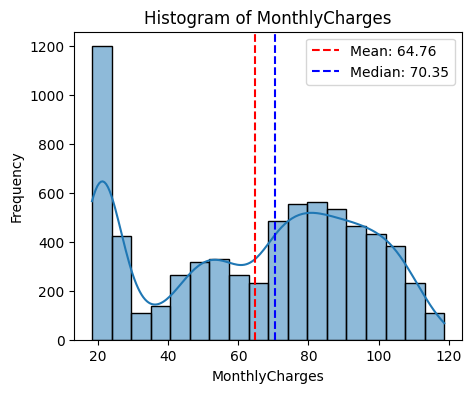

In [19]:
plot_histogram(df, 'MonthlyCharges')

In [20]:
df['TotalCharges_log'] = np.log1p(df['TotalCharges'])

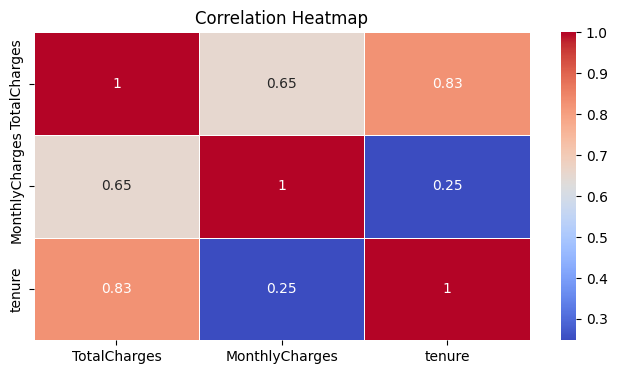

In [21]:
plt.figure(figsize=(8, 4))
sns.heatmap(df[['TotalCharges','MonthlyCharges', 'tenure']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Categorical Feature analysis

In [22]:
obj_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [23]:
obj_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [24]:
obj_cols = ['SeniorCitizen'] + obj_cols

Count plot for categorical column

In [25]:
# for col in obj_cols:
#     plt.figure(figsize=(6, 4))
#     sns.countplot(x=col, hue='Churn', data=df)
#     plt.title(f'Count Plot of {col} by Churn')
#     plt.xlabel(col)
#     plt.ylabel('Count')
#     plt.legend(title='Churn', loc='upper right')
#     plt.show()

In [26]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_log
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3.429137
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,7.544597
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4.692723
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,7.518471
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,5.028148


In [27]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# define column groups

In [28]:
# Already 0/1, no encoding needed
passthrough_cols = ["SeniorCitizen"]

# Yes/No binary → map to 1/0 manually before pipeline
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

# gender is Male/Female → map separately
# Multi-category → OneHotEncoder
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
]

# Numerical → StandardScaler + median impute for TotalCharges
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# STEP 3: Manual Pre-encoding (outside pipeline)

In [29]:
# Yes/No → 1/0
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# gender: Female → 1, Male → 0
df["gender"] = df["gender"].map({"Female": 1, "Male": 0})

# Target encoding
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID (not a feature)
df.drop(columns=["customerID"], inplace=True, errors="ignore")
 
# After manual encoding, binary + gender become numeric
all_numeric = numeric_cols + binary_cols + ["gender"] + passthrough_cols

In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_log
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,3.429137
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0,7.544597
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,4.692723
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,7.518471
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,5.028148


# STEP 4: Train-Test Split (BEFORE any SMOTE)

In [31]:
X = df.drop(columns=['Churn'])
y= df['Churn']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class ratio
)

In [33]:
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train Churn rate: {y_train.mean():.2%}")

Train shape: (5634, 20) | Test shape: (1409, 20)
Train Churn rate: 26.54%


# STEP 5: ColumnTransformer (Encoding Pipeline)

In [37]:
from imblearn.pipeline import Pipeline as ImbPipeline 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [35]:
print(all_numeric)
print(multi_cat_cols)

['tenure', 'MonthlyCharges', 'TotalCharges', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender', 'SeniorCitizen']
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [38]:
# Numeric: impute median (for TotalCharges NaNs) → scale

numeric_transformer = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Multi-category: OHE (drop='first' avoids dummy variable trap)

categorical_transformer = ImbPipeline(steps=[
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, all_numeric),
    ("cat", categorical_transformer, multi_cat_cols),
], remainder="drop")

In [43]:
# STEP 6: Handle Imbalance with SMOTE
#   Churn: No=5174 (73%) | Yes=1869 (27%)
#   SMOTE only on TRAIN set — never on test!
# ─────────────────────────────────────────────
#
#  Strategy 1: SMOTE inside imblearn Pipeline (recommended)
#  Strategy 2: class_weight='balanced' in model (simpler, no synthetic data)
#  We'll use BOTH for best results

# STEP 7: Build Model Pipelines

In [46]:
#Model A: Logistic Regression

lr_pipeline  = ImbPipeline(steps=[
    ("preprocessor",preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

#Model B: Random Forest

rf_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

#Model C: XGBoost
try:
    from xgboost import XGBClassifier
    # scale_pos_weight = count(No)/count(Yes) handles imbalance natively
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    xgb_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            scale_pos_weight=neg / pos,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
    XGB_AVAILABLE = True
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")
    XGB_AVAILABLE = False

# Model D: LightGBM
try:
    from lightgbm import LGBMClassifier
    lgbm_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
    ])
    LGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed. Run: pip install lightgbm")
    LGBM_AVAILABLE = False

# STEP 8: Quick Baseline Comparison (CV)

In [40]:
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
models = {"Logistic Regression": lr_pipeline, "Random Forest":rf_pipeline}
if XGB_AVAILABLE:   models["XGBoost"]  = xgb_pipeline
if LGBM_AVAILABLE:  models["LightGBM"] = lgbm_pipeline

In [47]:
print("\n" + "="*55)
print("  BASELINE CV SCORES (ROC-AUC, 5-fold StratifiedKFold)")
print("="*55)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"  {name:<22}: {scores.mean():.4f} ± {scores.std():.4f}")
 


  BASELINE CV SCORES (ROC-AUC, 5-fold StratifiedKFold)
  Logistic Regression   : 0.8452 ± 0.0133
  Random Forest         : 0.8219 ± 0.0128
  XGBoost               : 0.8226 ± 0.0076
  LightGBM              : 0.8335 ± 0.0088


# STEP 9: Hyperparameter Tuning (RandomizedSearch → GridSearch)

In [44]:
# Strategy: RandomizedSearch first (wide search, fast) →
#           GridSearch on the top candidates (narrow, precise)

In [48]:
# --- Tune Random Forest --

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5,10,15,20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 4],
    "model__max_features":      ["sqrt", "log2"],
    "smote__k_neighbors":       [3, 5, 7],              # tune SMOTE too
}

In [49]:
rf_random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = rf_param_dist,
    n_iter=30,  # number of random combinations to try
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

In [50]:
print("\nRunning RandomizedSearchCV for Random Forest...")
rf_random_search.fit(X_train, y_train)
print(f"Best RF ROC-AUC: {rf_random_search.best_score_:.4f}")
print(f"Best RF Params : {rf_random_search.best_params_}")


Running RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF ROC-AUC: 0.8446
Best RF Params : {'smote__k_neighbors': 5, 'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 10}


In [51]:
# --- Tune XGBoost (if available) ---
if XGB_AVAILABLE:
    xgb_param_dist = {
        "model__n_estimators":  [100, 200, 300, 500],
        "model__max_depth":     [3, 5, 7, 9],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample":     [0.6, 0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__gamma":         [0, 0.1, 0.2, 0.5],
        "model__reg_alpha":     [0, 0.01, 0.1],
        "model__reg_lambda":    [1, 1.5, 2],
    }

In [52]:
xgb_random_search = RandomizedSearchCV(
        estimator=xgb_pipeline,
        param_distributions=xgb_param_dist,
        n_iter=40,
        scoring="roc_auc",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        refit=True
    )

In [53]:
print("\nRunning RandomizedSearchCV for XGBoost...")
xgb_random_search.fit(X_train, y_train)
print(f"Best XGB ROC-AUC: {xgb_random_search.best_score_:.4f}")
print(f"Best XGB Params : {xgb_random_search.best_params_}")


Running RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB ROC-AUC: 0.8492
Best XGB Params : {'model__subsample': 0.6, 'model__reg_lambda': 2, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}


In [54]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "model__C":          [0.01, 0.1, 1, 10, 100],  # regularization
    "model__penalty":    ["l1", "l2"],               # L1 sparse karta hai
    "model__solver":     ["liblinear", "saga"],      # L1 ke liye zaroori
    "smote__k_neighbors": [3, 5, 7]
}

lr_search = RandomizedSearchCV(
    lr_pipeline,
    lr_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train, y_train)
print(f"Best LR ROC-AUC: {lr_search.best_score_:.4f}")
print(f"Best LR Params : {lr_search.best_params_}")

Best LR ROC-AUC: 0.8454
Best LR Params : {'smote__k_neighbors': 5, 'model__solver': 'saga', 'model__penalty': 'l2', 'model__C': 10}


In [ ]:
lgbm_param_dist = {
    "model__n_estimators":   [100, 200, 300],
    "model__max_depth":      [3, 5, 7, -1],
    "model__learning_rate":  [0.01, 0.05, 0.1],
    "model__num_leaves":     [15, 31, 63],
    "model__subsample":      [0.6, 0.8, 1.0],
    "smote__k_neighbors":    [3, 5, 7],
    "model__min_child_samples": [10, 20, 30],
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipeline,
    lgbm_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)
print(f"Best LGBM ROC-AUC: {lgbm_search.best_score_:.4f}")

In [58]:
final_results = {
    "LR (tuned)":    lr_search.best_score_,
    "RF (tuned)":    0.8446,
    "XGB (tuned)":   0.8492,
    "LGBM (tuned)":  lgbm_search.best_score_,
}

for name, score in sorted(final_results.items(), key=lambda x: -x[1]):
    print(f"  {name:<15}: {score:.4f}")

  XGB (tuned)    : 0.8492
  LR (tuned)     : 0.8454
  RF (tuned)     : 0.8446
  LGBM (tuned)   : 0.8437


# STEP 10: Final Evaluation on Test Set

In [59]:
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    print(f"\n{'='*55}")
    print(f"  {name} — TEST SET RESULTS")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return auc

In [61]:
# Evaluate best RF
best_rf_auc = evaluate_model(
    "Random Forest (tuned)",
    rf_random_search.best_estimator_,
    X_test, y_test
)
 
if XGB_AVAILABLE:
    best_xgb_auc = evaluate_model(
        "XGBoost (tuned)",
        xgb_random_search.best_estimator_,
        X_test, y_test
    )
best_lgbm_auc = evaluate_model(
    "LightGBM (tuned)",
    lgbm_search.best_estimator_,
    X_test, y_test
)

best_lr_auc = evaluate_model(
    "Logistic Regression (tuned)",
    lr_search.best_estimator_,
    X_test, y_test
)


  Random Forest (tuned) — TEST SET RESULTS
  ROC-AUC: 0.8420
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

Confusion Matrix:
[[819 216]
 [104 270]]

  XGBoost (tuned) — TEST SET RESULTS
  ROC-AUC: 0.8478
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409

Confusion Matrix:
[[761 274]
 [ 74 300]]

  LightGBM (tuned) — TEST SET RESULTS
  ROC-AUC: 0.8398
              precision    recall  f1-score   support

    No Churn       0.88      0.82 